## Settings

In [1]:
import sys
import scanpy as sc
import numpy as np
import pandas as pd
import anndata as ad
from scipy import sparse

import scvi
import rapids_singlecell as rsc

/mnt/data/project0062/.conda/envs/rapids_singlecell/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from pathlib import Path
import os

In [3]:
# %% Setting Paths
# setting paths
MAIN_DIR_NAME = "cosmx_gray"
MAIN_DIR = next(p for p in Path.cwd().parents if (p / MAIN_DIR_NAME).exists()) / MAIN_DIR_NAME
os.chdir(MAIN_DIR)

# %% Setting Seed
SEED_VALUE = 42
# set NumPy RNG for consistency
np.random.seed(42)

In [4]:
# %% Set paths for model 

ref_model_dir_prefix = MAIN_DIR / 'data' / 'reference'  # directory in which to store the reference model directory

path_reference_emb = (
    MAIN_DIR / 'data' / 'reference' / 'adata_ref.h5ad'  # path to reference embedding to be created
)
path_query_data = (
    MAIN_DIR / 'data' / 'reference' / 'adata_query.h5ad'  # path to reference embedding to be created
)  # input test query data

# don't change the following paths:
ref_model_dir = os.path.join(
    ref_model_dir_prefix, "merged_model"
)  # don't change this


## Merge the datasets

Load the query dataset

In [5]:
# query dataset
adata_query = sc.read_h5ad(path_query_data) 
# reference dataset 
adata_ref = sc.read_h5ad(path_reference_emb)


In [7]:
adata_query.layers["counts"] = adata_query.X.copy()
adata_query.obs['cell_type'] = 'unknown' # rename label to cell_type for consistency

In [9]:
# combine both datasets for transfer learning
adata_combined = ad.concat([adata_ref, adata_query], join="outer", label="batch", keys=["ref", "query"])

/tmp/ipykernel_1719101/3822481637.py:2: UserWarning: Only some AnnData objects have `.raw` attribute, not concatenating `.raw` attributes.
  adata_combined = ad.concat([adata_ref, adata_query], join="outer", label="batch", keys=["ref", "query"])


integrate the data with scVI

In [10]:
# integrate teh data with scVI
scvi.model.SCVI.setup_anndata(
    adata_combined,
    batch_key="batch",
)

/mnt/data/project0062/.conda/envs/rapids_singlecell/lib/python3.13/site-packages/scvi/data/fields/_base_field.py:63: UserWarning: adata.X does not contain unnormalized count data. Are you sure this is what you want?
  self.validate_field(adata)


In [11]:
scvi_model = scvi.model.SCVI(adata_combined, n_layers=2, n_latent=30, gene_likelihood="nb")

In [12]:
scvi_model.train()

/mnt/data/project0062/.conda/envs/rapids_singlecell/lib/python3.13/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /mnt/data/project0062/.conda/envs/rapids_singlecell/ ...
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/mnt/data/project0062/.conda/envs/rapids_singlecell/lib/python3.13/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /mnt/data/project0062/.conda/envs/rapids_singlecell/ ...
You are using a CUDA device ('NVIDIA A40') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('me

Epoch 4/4: 100%|██████████| 4/4 [09:07<00:00, 134.31s/it, v_num=1, train_loss_step=1.33e+3, train_loss_epoch=1.17e+3]

`Trainer.fit` stopped: `max_epochs=4` reached.


Epoch 4/4: 100%|██████████| 4/4 [09:07<00:00, 136.97s/it, v_num=1, train_loss_step=1.33e+3, train_loss_epoch=1.17e+3]


In [13]:
SCVI_LATENT_KEY = "X_scVI"
adata_combined.obsm[SCVI_LATENT_KEY] = scvi_model.get_latent_representation()

In [14]:
rsc.pp.neighbors(adata_combined, use_rep=SCVI_LATENT_KEY)
rsc.tl.umap(adata_combined, min_dist=0.3)

... storing 'cell_type' as categorical
... storing 'observation_joinid' as categorical
... storing 'cell' as categorical


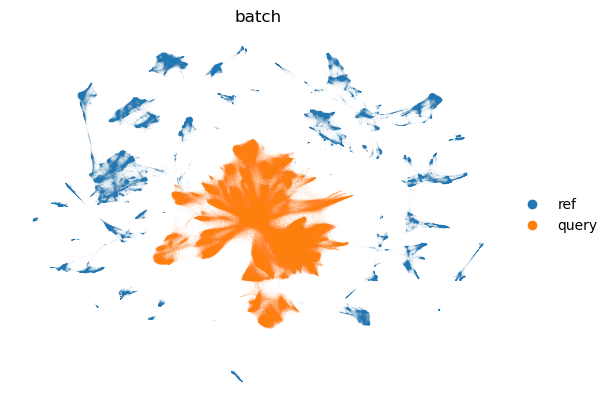

In [15]:

sc.pl.umap(
    adata_combined,
    color=["batch"],
    frameon=False,
    ncols=1,
)

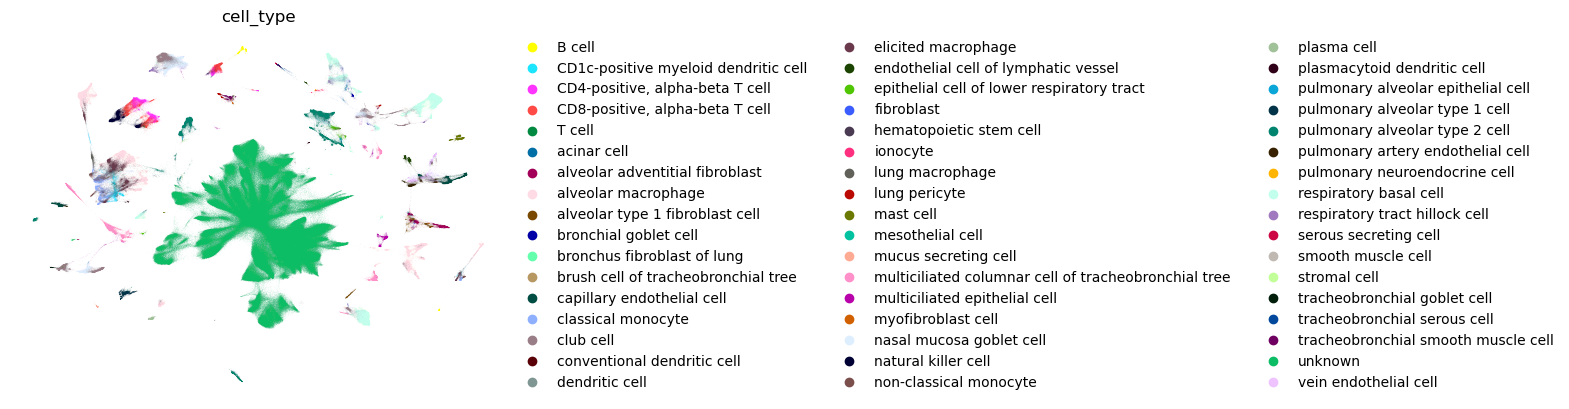

In [16]:
sc.pl.umap(
    adata_combined,
    color=["cell_type"],
    frameon=False,
    ncols=1,
)

## transfer of annotatiosn with scANVI

In [17]:
scanvi_model = scvi.model.SCANVI.from_scvi_model(
    scvi_model,
    adata=adata_combined,
    unlabeled_category="unknown",
    labels_key='cell_type',
)

/mnt/data/project0062/.conda/envs/rapids_singlecell/lib/python3.13/site-packages/scvi/data/fields/_base_field.py:63: UserWarning: adata.X does not contain unnormalized count data. Are you sure this is what you want?
  self.validate_field(adata)


In [18]:
scanvi_model.train(max_epochs=20, n_samples_per_label=100)

INFO     Training for 20 epochs.                                                                                   


/mnt/data/project0062/.conda/envs/rapids_singlecell/lib/python3.13/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /mnt/data/project0062/.conda/envs/rapids_singlecell/ ...
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/mnt/data/project0062/.conda/envs/rapids_singlecell/lib/python3.13/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /mnt/data/project0062/.conda/envs/rapids_singlecell/ ...
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/mnt/data/project0062/.conda/envs/rapids_singlecell/lib/python3.13/site-packages/lightning/pytorch/train

Epoch 20/20: 100%|██████████| 20/20 [1:30:14<00:00, 258.87s/it, v_num=1, train_loss_step=1.06e+3, train_loss_epoch=1.15e+3]

`Trainer.fit` stopped: `max_epochs=20` reached.


Epoch 20/20: 100%|██████████| 20/20 [1:30:14<00:00, 270.74s/it, v_num=1, train_loss_step=1.06e+3, train_loss_epoch=1.15e+3]


In [19]:
SCANVI_LATENT_KEY = "X_scANVI"
SCANVI_PREDICTION_KEY = "C_scANVI"

adata_combined.obsm[SCANVI_LATENT_KEY] = scanvi_model.get_latent_representation(adata_combined)
adata_combined.obs[SCANVI_PREDICTION_KEY] = scanvi_model.predict(adata_combined)

In [20]:
rsc.pp.neighbors(adata_combined, use_rep=SCANVI_LATENT_KEY)
rsc.tl.umap(adata_combined, min_dist=0.3)

... storing 'C_scANVI' as categorical


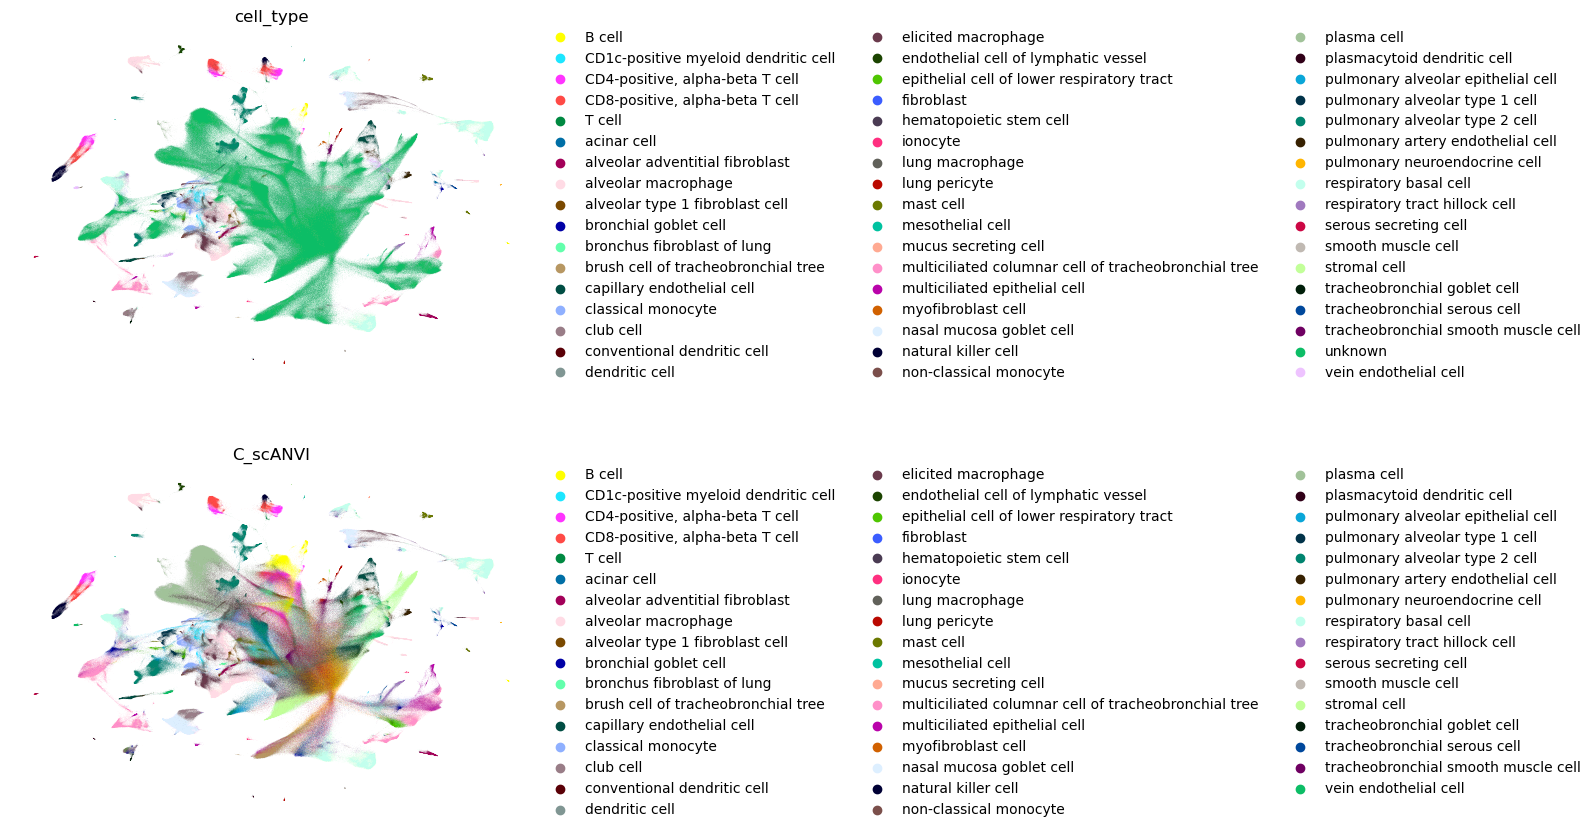

In [21]:
sc.pl.umap(
    adata_combined,
    color=["cell_type", SCANVI_PREDICTION_KEY],
    frameon=False,
    ncols=1,
)

In [23]:
# save annotated object
adata_combined.write_h5ad(
    MAIN_DIR / "data" / "reference" / "adata_combined_scANVI.h5ad"
)